In [9]:
# packages
using Markdown
using InteractiveUtils
using NonlinearSolve
using StaticArrays
# files
using PKAssetPrices
import PKAssetPrices.Static: Parametrization, Model
using CairoMakie 
using OrderedCollections

In [13]:
sols  = OrderedDict(
    "Baseline" => solve_model(Static.AssetPKPQ),
    "PQCr"   => solve_model(Static.AssetPKPQCr),
    "PQC"   => solve_model(Static.AssetPKPQC),
    "PQCrDiff"   => solve_model(Static.AssetPKPQCrDIFF),
    "PQA" => solve_model(Static.AssetPKPQA)
)

OrderedDict{String, PKAssetPrices.Static.Solution} with 5 entries:
  "Baseline" => Solution(16 vars, 3 sheets)
  "PQCr"     => Solution(17 vars, 3 sheets)
  "PQC"      => Solution(17 vars, 3 sheets)
  "PQCrDiff" => Solution(17 vars, 3 sheets)
  "PQA"      => Solution(17 vars, 3 sheets)

### Plot Differences

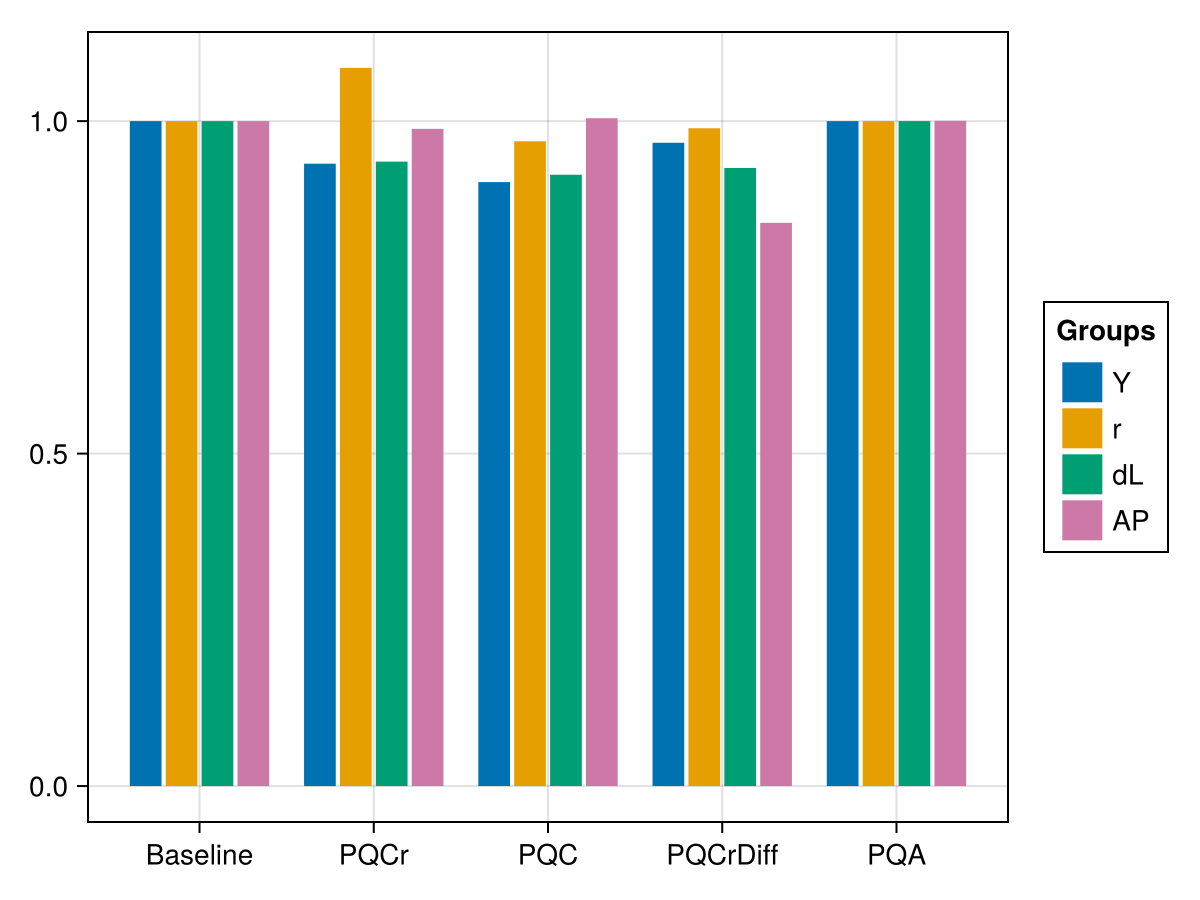

In [16]:
Static.bar_chart(sols, [:Y,:r, :dL,:AP])

In [19]:
Static.build_table_from_solutions(values(sols) |> collect, ["Baseline", "PQCr","PQC", "PQCrDiff", "PQA"])

Variable,Scenario 1: Baseline,Scenario 2: PQCr,Scenario 3: PQC,Scenario 4: PQCrDiff,Scenario 5: PQA
Y,6.566017914628954,6.145636776401819,5.96394779216177,6.352449637008641,6.566017914628955
ND,3.283008957314477,3.0728183882009095,2.981973896080885,3.1762248185043207,3.2830089573144776
D,4.103761196643096,4.032043822151066,4.130939444731428,4.1134019534525805,4.103761196643096
i,0.09741726123444606,0.10521262802705805,0.09446310383354041,0.09636935288558905,0.09741726123444606
r,0.11202985041961297,0.12099452223111674,0.10863256940857147,0.1108247558184274,0.11202985041961298
P,1.7483452246889213,1.7070918223242317,1.6892620766708082,1.7273870577117811,1.7483452246889215
dL,3.6699681469484218,3.4464433871267737,3.3740268388672194,3.4113806093157173,3.6701309346369446
dM,3.6699681469484218,3.4464433871267737,3.3740268388672194,3.4113806093157173,3.6701309346369446
dR,1.1009904440845264,1.033933016138032,1.0122080516601657,1.0234141827947152,1.1010392803910833
W,1.9003752442270885,1.8555345894828608,1.8361544311639222,1.8775946279475884,1.9003752442270887


### Get Balance Sheets

In [9]:
display(html"<h3>Baseline</h3>")
display(sol1.sheets)
display(html"<h3>with s2=1</h3>")
display(sol2.sheets)
display(html"<h3>with s2=0.8</h3>")
display(sol_scen1a.sheets)

HTML{String}("<h3>Baseline</h3>")

Assets,Value,Liabilities,Value
Deposits,3.67,Loans,3.67
Total,3.67,Total,3.67
Assets,Value,Liabilities,Value
Loans,3.67,Deposits,3.67
Reserves,1.1,Central Bank Credit,1.1
Total,4.77,Total,4.77
Assets,Value,Liabilities,Value
Central Bank Credit,1.1,Reserves,1.1
Total,1.1,Total,1.1


HTML{String}("<h3>with s2=1</h3>")

Assets,Value,Liabilities,Value
Deposits,3.67,Loans,3.67
Total,3.67,Total,3.67
Assets,Value,Liabilities,Value
Loans,3.67,Deposits,3.67
Reserves,1.1,Central Bank Credit,1.1
Total,4.77,Total,4.77
Assets,Value,Liabilities,Value
Central Bank Credit,1.1,Reserves,1.1
Total,1.1,Total,1.1


HTML{String}("<h3>with s2=0.8</h3>")

Assets,Value,Liabilities,Value
Deposits,4.25,Loans,4.25
Total,4.25,Total,4.25
Assets,Value,Liabilities,Value
Loans,4.25,Deposits,4.25
Reserves,1.27,Central Bank Credit,1.27
Total,5.52,Total,5.52
Assets,Value,Liabilities,Value
Central Bank Credit,1.27,Reserves,1.27
Total,1.27,Total,1.27


### Show Curves

In [20]:
solution = solve_model(Static.AssetPKQ)
r_eq = solution.variables[:r]

y_eq = solution.variables[:Y]

# Build a range of r values around the equilibrium for IS
r_min = r_eq * 0.2
r_max = r_eq * 3.0
r_range = range(r_min, r_max; length = 200)

# Build a range of Y values around the equilibrium for IR
y_min = y_eq * 0.2
y_max = y_eq * 3.0
y_range = range(y_min, y_max; length = 200)

# IS curve: r → Y  (plot as x=r, y=IS(r))
is_values = Float64[]
for r in r_range
    vars = copy(solution.variables)
    vars[:r] = r
    curves = Static.eval_curve(solution.model, vars)
    push!(is_values, curves.IS)
end
# IR curve: Y → r  (plot as x=IR(Y), y=Y so both axes match)
ir_r_values = Float64[]
for y in y_range
    vars = copy(solution.variables)
    vars[:Y] = y
    curves = Static.eval_curve(solution.model, vars)
    push!(ir_r_values, curves.IR)
end
f = Figure()
a = Axis(f[1, 1], title = "IS curve", xlabel = "r", ylabel = "Y")
lines!(a, ir_r_values, y_range)
lines!(a, r_range, is_values)
f

In [23]:
    # Get the equilibrium values
    AP_eq = solution.variables[:AP]
    AS_eq = solution.variables[:AS]

    # Build a range of r values around the equilibrium for IS
    AP_min = AP_eq * 0.2
    AP_max = AP_eq * 3.0
    AP_range = range(AP_min, AP_max; length = 200)


    # IS curve: r → Y  (plot as x=r, y=IS(r))
    ad_values = Float64[]
    as_values = Float64[]
    for AP in AP_range
        vars = copy(solution.variables)
        vars[:AP] = AP
        curves = Static.eval_curve(solution.model, vars)
        push!(ad_values, curves.AMD)
        push!(as_values, curves.AMS)
    end
f = Figure()
a = Axis(f[1, 1], title = "IS curve", xlabel = "Q", ylabel = "AP")
lines!(a, ad_values, AP_range)
lines!(a, AP_range, as_values)
f